# Clasificación de prendas con Fashion MNIST y TensorFlow

**Objetivo:** descargar el data set Fashion MNIST con TensorFlow, clasificar prendas de vestir con una **red neuronal de dos capas ocultas**, probar el modelo, reportar la precisión obtenida y sacar conclusiones.

Fashion MNIST tiene 70.000 imágenes en escala de grises de 28×28 píxeles (60.000 de entrenamiento y 10.000 de prueba) y 10 clases de prendas. Cada píxel va de 0 (negro) a 255 (blanco).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report

# Semillas para resultados aproximadamente reproducibles
np.random.seed(42)
tf.random.set_seed(42)
print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.20.0


## 2. Descargar y explorar el data set
`keras.datasets.fashion_mnist.load_data()` lo descarga automáticamente. Las etiquetas vienen como números 0-9, por lo que definimos sus nombres.

In [9]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ["Camiseta/Top", "Pantalón", "Suéter", "Vestido", "Abrigo",
               "Sandalia", "Camisa", "Zapatilla deportiva", "Bolso", "Botín"]

print("Entrenamiento (imágenes):", X_train_full.shape)
print("Entrenamiento (etiquetas):", y_train_full.shape)
print("Prueba (imágenes):       ", X_test.shape)
print("Prueba (etiquetas):      ", y_test.shape)
print("Rango de píxeles:", X_train_full.min(), "a", X_train_full.max())

Entrenamiento (imágenes): (60000, 28, 28)
Entrenamiento (etiquetas): (60000,)
Prueba (imágenes):        (10000, 28, 28)
Prueba (etiquetas):       (10000,)
Rango de píxeles: 0 a 255


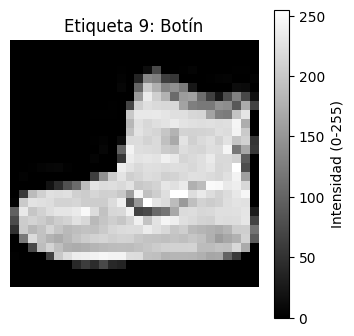

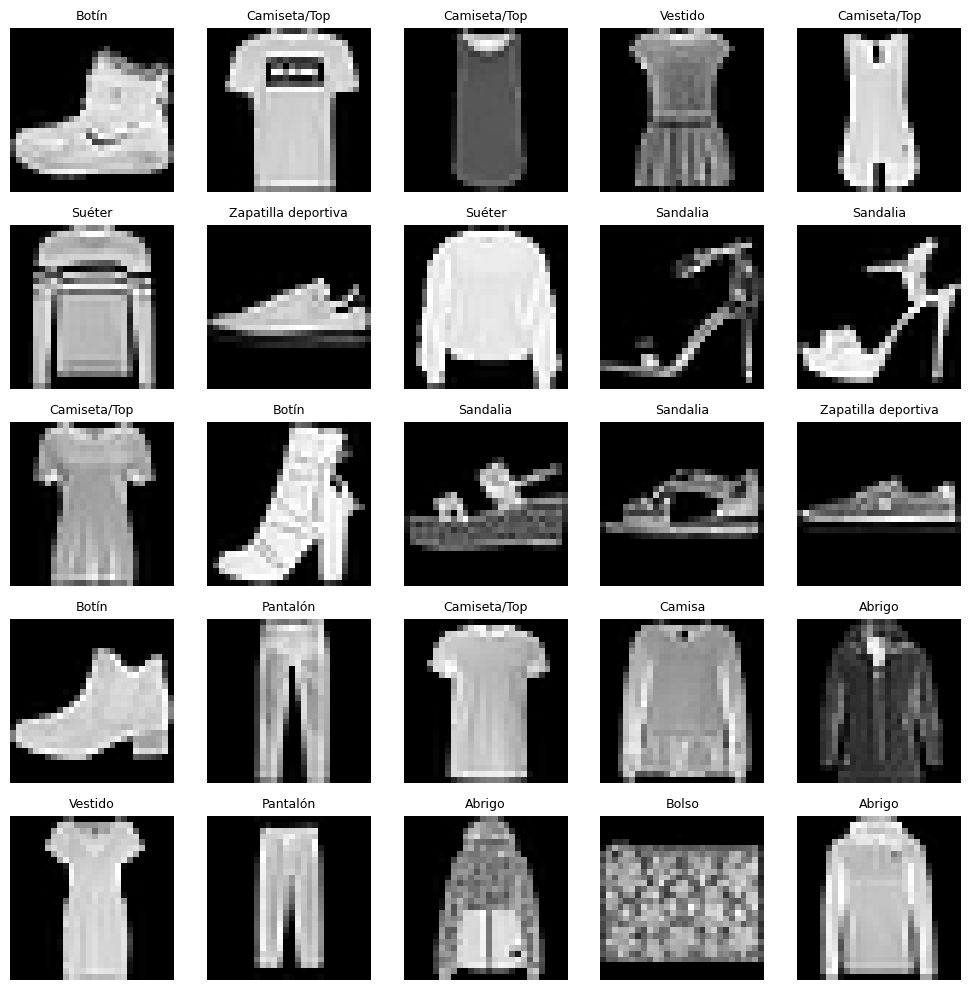

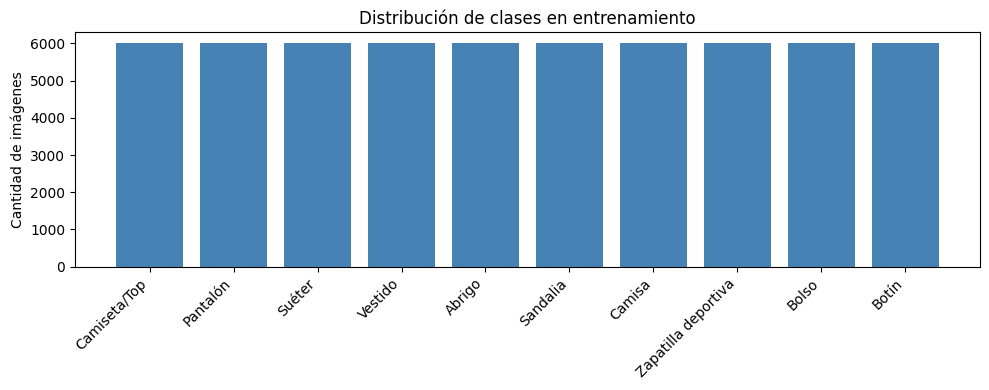

In [10]:
# Una imagen
plt.figure(figsize=(4, 4))
plt.imshow(X_train_full[0], cmap="gray")
plt.colorbar(label="Intensidad (0-255)")
plt.title(f"Etiqueta {y_train_full[0]}: {class_names[y_train_full[0]]}")
plt.axis("off")
plt.show()

# Cuadrícula de 25 ejemplos
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Distribución de clases (¿está balanceado?)
conteo = np.bincount(y_train_full)
plt.figure(figsize=(10, 4))
plt.bar(class_names, conteo, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de clases en entrenamiento")
plt.tight_layout()
plt.show()

## 3. Preprocesamiento
- **Normalización:** se divide entre 255 para llevar los píxeles a [0, 1]. Las redes entrenan mejor con entradas de escala pequeña.
- **Validación:** se separan 5.000 ejemplos de entrenamiento para monitorear el sobreajuste sin tocar el conjunto de prueba.

| Conjunto | Tamaño | Uso |
|---|---|---|
| Entrenamiento | 55.000 | Ajustar pesos |
| Validación | 5.000 | Monitoreo durante el entrenamiento |
| Prueba | 10.000 | Evaluación final |

In [11]:
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

print("Entrenamiento:", X_train.shape)
print("Validación:   ", X_valid.shape)
print("Prueba:       ", X_test.shape)

Entrenamiento: (55000, 28, 28)
Validación:    (5000, 28, 28)
Prueba:        (10000, 28, 28)


## 4. Modelo: red neuronal con dos capas ocultas

| Capa | Detalle | Función |
|---|---|---|
| `Flatten` | 28×28 → 784 | Convierte la imagen en un vector |
| **Oculta 1** | `Dense` 128, ReLU | Aprende patrones básicos |
| **Oculta 2** | `Dense` 64, ReLU | Combina patrones en características más complejas |
| Salida | `Dense` 10, Softmax | Probabilidad de cada clase |

**ReLU** (`max(0, x)`) aporta la no linealidad y es rápida. **Softmax** convierte la salida en probabilidades que suman 1, ideal para multiclase.

Parámetros: 784·128+128 = 100.480; 128·64+64 = 8.256; 64·10+10 = 650. **Total: 109.386.**

In [12]:
model = keras.models.Sequential([
    keras.Input(shape=[28, 28], name="entrada_aplanada"),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu", name="oculta_1"),
    keras.layers.Dense(64, activation="relu", name="oculta_2"),
    keras.layers.Dense(10, activation="softmax", name="salida"),
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compilación y entrenamiento
- **Pérdida:** `sparse_categorical_crossentropy`, porque las etiquetas son enteros y no one-hot.
- **Optimizador:** `adam`, que adapta la tasa de aprendizaje.
- **Métrica:** `accuracy`.
- **EarlyStopping:** detiene el entrenamiento si `val_loss` no mejora en 5 épocas y restaura los mejores pesos, lo que evita el sobreajuste.

In [13]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                           restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=30, batch_size=32,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stop], verbose=1)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8213 - loss: 0.5002 - val_accuracy: 0.8670 - val_loss: 0.3698
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8625 - loss: 0.3733 - val_accuracy: 0.8734 - val_loss: 0.3509
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8758 - loss: 0.3350 - val_accuracy: 0.8822 - val_loss: 0.3276
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8844 - loss: 0.3097 - val_accuracy: 0.8838 - val_loss: 0.3250
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8911 - loss: 0.2896 - val_accuracy: 0.8792 - val_loss: 0.3333
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8974 - loss: 0.2734 - val_accuracy: 0.8818 - val_loss: 0.3328
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9013 - loss: 0.2611 - val_accuracy: 0.8852 - val_loss: 0.3254
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9057 - loss: 0.2497 -

## 6. Curvas de aprendizaje
Si la precisión de entrenamiento sube pero la de validación se estanca y su pérdida sube, hay **sobreajuste**.

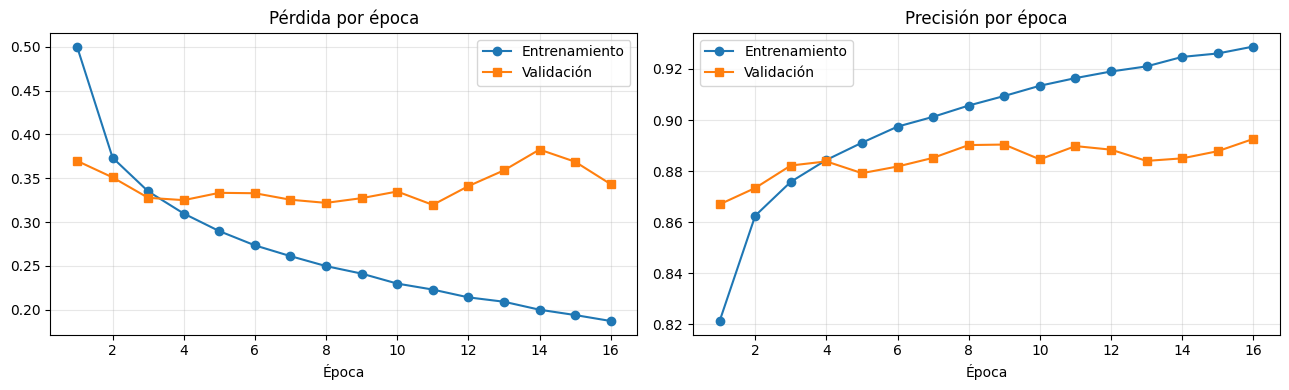

Épocas ejecutadas: 16
Precisión final entrenamiento: 0.9288
Precisión final validación:    0.8926


In [14]:
hist = history.history
epocas = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epocas, hist["loss"], "o-", label="Entrenamiento")
axes[0].plot(epocas, hist["val_loss"], "s-", label="Validación")
axes[0].set_title("Pérdida por época"); axes[0].set_xlabel("Época"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(epocas, hist["accuracy"], "o-", label="Entrenamiento")
axes[1].plot(epocas, hist["val_accuracy"], "s-", label="Validación")
axes[1].set_title("Precisión por época"); axes[1].set_xlabel("Época"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"Épocas ejecutadas: {len(epocas)}")
print(f"Precisión final entrenamiento: {hist['accuracy'][-1]:.4f}")
print(f"Precisión final validación:    {hist['val_accuracy'][-1]:.4f}")

## 7. Evaluación en el conjunto de prueba
Se prueba el modelo con las 10.000 imágenes que nunca vio. **Este es el resultado que responde: ¿qué precisión obtuvo?**

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("=" * 50)
print(f"  PRECISIÓN EN PRUEBA: {test_acc:.4f}  ({test_acc*100:.2f} %)")
print(f"  Pérdida en prueba:   {test_loss:.4f}")
print("=" * 50)

  PRECISIÓN EN PRUEBA: 0.8848  (88.48 %)
  Pérdida en prueba:   0.3501


## 8. Predicciones
`model.predict` devuelve 10 probabilidades por imagen; la clase predicha es la de mayor probabilidad (`argmax`). En las gráficas, 🔵 azul = acierto y 🔴 rojo = error (entre paréntesis, la clase real).

Probabilidades de la imagen 0:
  Camiseta/Top           0.000
  Pantalón               0.000
  Suéter                 0.000
  Vestido                0.000
  Abrigo                 0.000
  Sandalia               0.059
  Camisa                 0.000
  Zapatilla deportiva    0.023
  Bolso                  0.000
  Botín                  0.918

→ Predicción: Botín | Real: Botín
Primeras 12 imágenes de prueba:


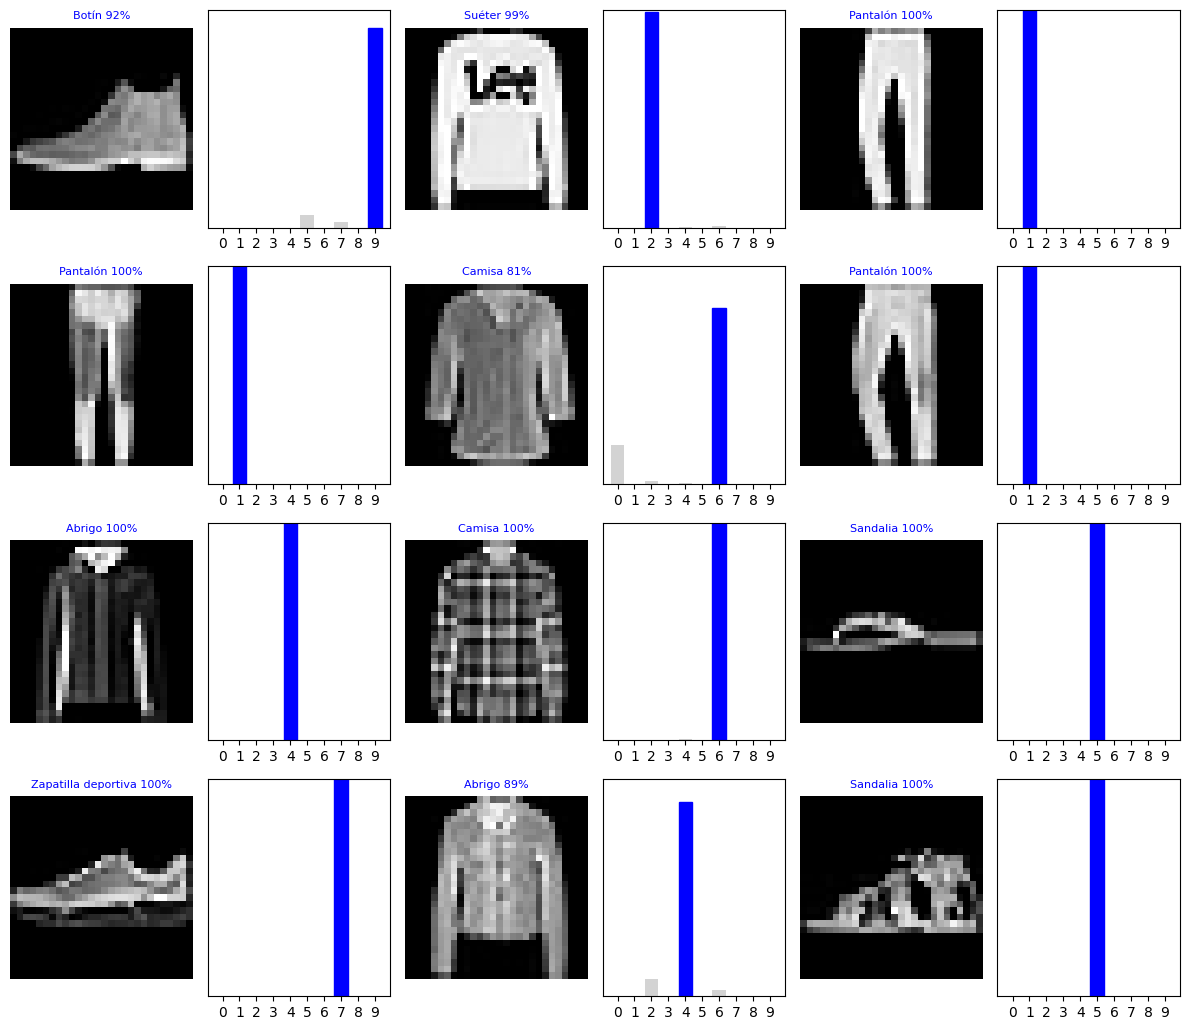

Total de errores: 1152 de 10000


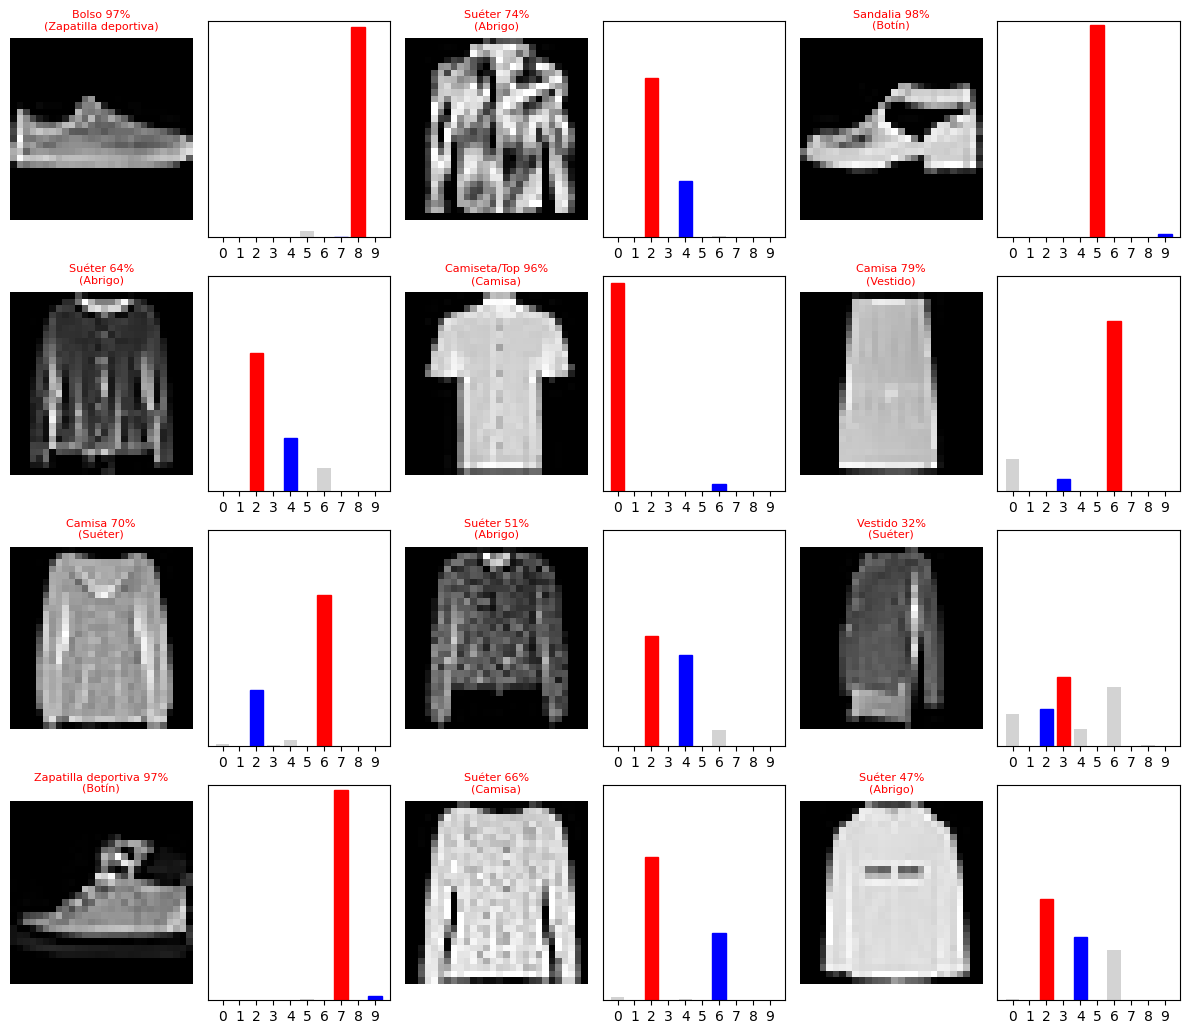

In [16]:
y_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

print("Probabilidades de la imagen 0:")
for nombre, p in zip(class_names, y_proba[0]):
    print(f"  {nombre:22s} {p:.3f}")
print(f"\n→ Predicción: {class_names[y_pred[0]]} | Real: {class_names[y_test[0]]}")


def mostrar_predicciones(indices):
    n = len(indices)
    filas = (n + 2) // 3
    plt.figure(figsize=(12, 2.6 * filas))
    for k, idx in enumerate(indices):
        acierto = y_pred[idx] == y_test[idx]
        color = "blue" if acierto else "red"

        plt.subplot(filas, 6, 2 * k + 1)
        plt.imshow(X_test[idx], cmap="gray"); plt.axis("off")
        et = f"{class_names[y_pred[idx]]} {100*y_proba[idx].max():.0f}%"
        if not acierto:
            et += f"\n({class_names[y_test[idx]]})"
        plt.title(et, color=color, fontsize=8)

        plt.subplot(filas, 6, 2 * k + 2)
        barras = plt.bar(range(10), y_proba[idx], color="lightgray")
        barras[y_pred[idx]].set_color("red")
        barras[y_test[idx]].set_color("blue")
        plt.xticks(range(10)); plt.ylim(0, 1); plt.yticks([])
    plt.tight_layout(); plt.show()


print("Primeras 12 imágenes de prueba:")
mostrar_predicciones(list(range(12)))

errores = np.where(y_pred != y_test)[0]
print(f"Total de errores: {len(errores)} de {len(y_test)}")
mostrar_predicciones(list(errores[:12]))

## 9. Matriz de confusión y métricas por clase
La precisión global no dice *dónde* falla el modelo. La matriz de confusión muestra, para cada clase real (filas), qué predijo el modelo (columnas).

- **Precision:** de lo que el modelo llamó "X", qué fracción lo era realmente.
- **Recall:** de todas las prendas realmente "X", qué fracción detectó.
- **F1:** media armónica de ambas.

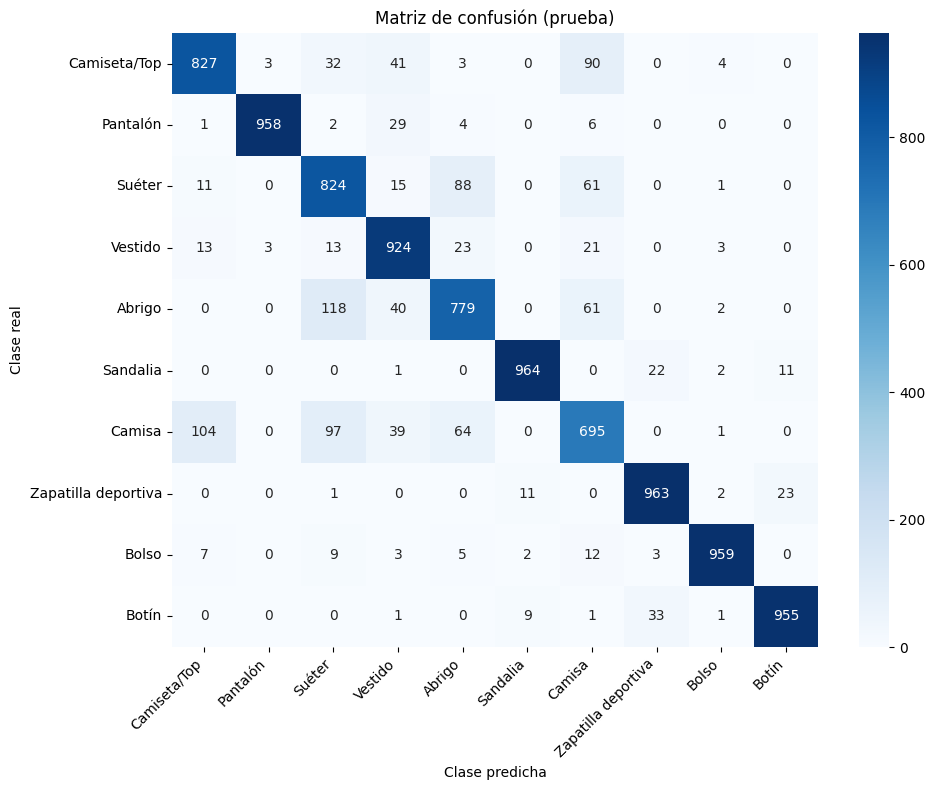

                     precision    recall  f1-score   support

       Camiseta/Top      0.859     0.827     0.843      1000
           Pantalón      0.994     0.958     0.976      1000
             Suéter      0.752     0.824     0.786      1000
            Vestido      0.845     0.924     0.883      1000
             Abrigo      0.806     0.779     0.792      1000
           Sandalia      0.978     0.964     0.971      1000
             Camisa      0.734     0.695     0.714      1000
Zapatilla deportiva      0.943     0.963     0.953      1000
              Bolso      0.984     0.959     0.971      1000
              Botín      0.966     0.955     0.960      1000

           accuracy                          0.885     10000
          macro avg      0.886     0.885     0.885     10000
       weighted avg      0.886     0.885     0.885     10000



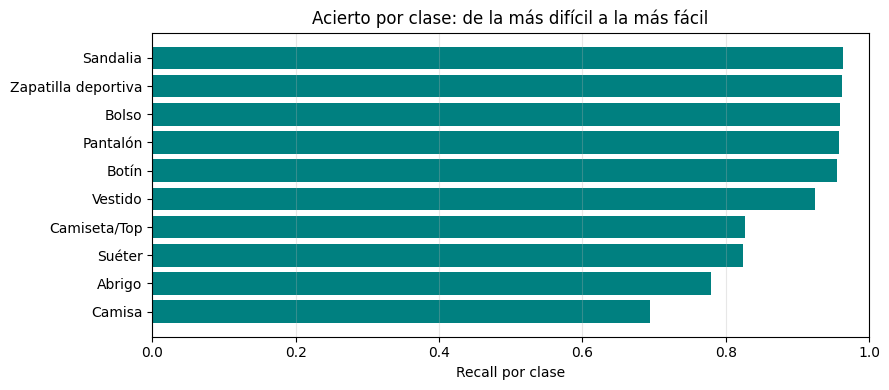

Las 5 confusiones más frecuentes (real → predicha):
  Abrigo               → Suéter              : 118 veces
  Camisa               → Camiseta/Top        : 104 veces
  Camisa               → Suéter              : 97 veces
  Camiseta/Top         → Camisa              : 90 veces
  Suéter               → Abrigo              : 88 veces


In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Clase predicha"); plt.ylabel("Clase real")
plt.title("Matriz de confusión (prueba)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

# Acierto por clase
acc_por_clase = cm.diagonal() / cm.sum(axis=1)
orden = np.argsort(acc_por_clase)
plt.figure(figsize=(9, 4))
plt.barh([class_names[i] for i in orden], acc_por_clase[orden], color="teal")
plt.xlim(0, 1); plt.xlabel("Recall por clase")
plt.title("Acierto por clase: de la más difícil a la más fácil")
plt.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

# Confusiones más frecuentes
cm_nd = cm.copy(); np.fill_diagonal(cm_nd, 0)
print("Las 5 confusiones más frecuentes (real → predicha):")
top = np.dstack(np.unravel_index(np.argsort(-cm_nd.ravel())[:5], cm.shape))[0]
for real, pred in top:
    print(f"  {class_names[real]:20s} → {class_names[pred]:20s}: {cm_nd[real, pred]} veces")

In [18]:
print("RESUMEN DEL EXPERIMENTO")
print("-" * 50)
print("Arquitectura:              784 → 128 → 64 → 10")
print(f"Parámetros entrenables:    {model.count_params():,}")
print(f"Épocas ejecutadas:         {len(epocas)}")
print(f"Precisión entrenamiento:   {hist['accuracy'][-1]*100:.2f} %")
print(f"Precisión validación:      {hist['val_accuracy'][-1]*100:.2f} %")
print(f"Precisión PRUEBA:          {test_acc*100:.2f} %")
print(f"Brecha entrenamiento-prueba: {(hist['accuracy'][-1]-test_acc)*100:.2f} puntos")
print(f"Clase más fácil:   {class_names[orden[-1]]} ({acc_por_clase[orden[-1]]*100:.1f} %)")
print(f"Clase más difícil: {class_names[orden[0]]} ({acc_por_clase[orden[0]]*100:.1f} %)")

RESUMEN DEL EXPERIMENTO
--------------------------------------------------
Arquitectura:              784 → 128 → 64 → 10
Parámetros entrenables:    109,386
Épocas ejecutadas:         16
Precisión entrenamiento:   92.88 %
Precisión validación:      89.26 %
Precisión PRUEBA:          88.48 %
Brecha entrenamiento-prueba: 4.40 puntos
Clase más fácil:   Sandalia (96.4 %)
Clase más difícil: Camisa (69.5 %)


## 10. Conclusiones

> Los valores exactos varían un poco entre ejecuciones. Con esta arquitectura lo habitual es una precisión en prueba de ~87–89 %. Ajuste las cifras a las de su celda de resumen.

1. **Desempeño general:** la red con dos capas ocultas (128 y 64 neuronas) alcanza una precisión alta en prueba, muy superior al azar (10 %), con una arquitectura simple y pocos minutos de entrenamiento.
2. **Sobreajuste moderado:** la precisión de entrenamiento suele superar a la de validación y prueba por unos pocos puntos. `EarlyStopping` ayudó a frenarlo, pero la brecha no desaparece del todo.
3. **Clases fáciles vs. difíciles:** pantalón, bolso, botín, zapatilla y sandalia se clasifican muy bien por sus formas distintivas. Camisa, camiseta/top, suéter y abrigo se confunden entre sí porque, a 28×28 y en gris, sus siluetas son casi idénticas. La **camisa** suele ser la más difícil.
4. **Limitación de la arquitectura:** `Flatten` trata cada píxel como variable independiente y pierde la estructura espacial de la imagen, lo que impone un techo cercano al 89–90 %.
5. **Data set balanceado:** al tener igual cantidad de imágenes por clase, la *accuracy* es una métrica confiable aquí.

### Posibles mejoras
- **Redes convolucionales (CNN):** aprovechan la estructura 2D y suelen superar el 91–93 % en este data set.
- **Regularización:** `Dropout`, penalización L2 o *data augmentation*.
- **Hiperparámetros:** más neuronas o capas, otra tasa de aprendizaje, otro tamaño de lote.
- **`ReduceLROnPlateau`** para ajustar la tasa de aprendizaje dinámicamente.